In [18]:
import pandas as pd 
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from scipy.stats.contingency import association

In [19]:
files = "subsampled_comments - REAL_subsampled_comments.csv"
source = "../backups/exp_no_hist.csv"
names = ["Vibecoding", "SideProject"]

In [20]:
files_df = pd.read_csv(files)
files_df.drop_duplicates(inplace=True)
source_df = pd.read_csv(source, index_col=0)
source_df.drop_duplicates(inplace=True)

In [21]:
files_df.head()

,Unnamed: 0,url,commit,proj_name,file_path,file_name,new_url,comments,Notes,Code A,m,double check,Why,AI typesetting,syntax error,human-like,Fun Comment
0,213881.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/tests/integration/test_routin...,test_routing.py,https://github.com/Egham-7/adaptive/blob/03c44...,"""""""Test that alternatives has reasonab...",NaN,Control flow/program logic,Control flow/program logic,False,False,False,False,False,False
1,214192.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/src/nordlys/clustering/spectr...,spectral.py,https://github.com/Egham-7/adaptive/blob/03c44...,"\n def predict(self, embeddings: np.ndarray...",NaN,Structured Docstring,NaN,False,False,False,False,False,False
2,178359.0,https://github.com/hh54188/ai-assistant-chrome...,99df8d7adc5d5d2925bfa3bcbca4e4afbdb1d88e,ai-assistant-chrome-extension,ai-assistant-chrome-extension/agents/adk-agent...,github_operations.py,https://github.com/hh54188/ai-assistant-chrome...,"repo = g.get_repo(""hh54188/horace-jeky...",NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False
3,324344.0,https://github.com/Ark0N/AI-Code-Executor,acdbbd5116a8aa932e71ac18aa90d66144d7123c,AI-Code-Executor,AI-Code-Executor/backend/main.py,main.py,https://github.com/Ark0N/AI-Code-Executor/blob...,"@app.get(""/api/models/lmstudio"")\nasync def ge...",NaN,Docstring,NaN,False,False,False,False,False,False
4,332211.0,https://github.com/TaimoorKhan10/AI-Fairness-E...,74ad5f68c942943abfc85c714bb09c4245c583e4,AI-Fairness-Explainability-Toolkit,AI-Fairness-Explainability-Toolkit/afet/tests/...,test_model_comparison.py,https://github.com/TaimoorKhan10/AI-Fairness-E...,from sklearn.model_selection import train_test...,NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False


In [22]:
mask = (source_df["Vibecoding"])
name_df = source_df[mask]
url_set = set(name_df["url"])

In [23]:
files_df["source"] =  ["Vibecoding" if x in url_set else "SideProject" for x in files_df['url']]

In [24]:
print(files_df["source"][int(files_df.index[files_df.proj_name == "Anubis"].max())])
print(files_df["source"][int(files_df.index[files_df.proj_name == "Ben-s-Software-"].max())])

SideProject
Vibecoding


In [25]:
files_df.head()

,Unnamed: 0,url,commit,proj_name,file_path,file_name,new_url,comments,Notes,Code A,m,double check,Why,AI typesetting,syntax error,human-like,Fun Comment,source
0,213881.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/tests/integration/test_routin...,test_routing.py,https://github.com/Egham-7/adaptive/blob/03c44...,"""""""Test that alternatives has reasonab...",NaN,Control flow/program logic,Control flow/program logic,False,False,False,False,False,False,Vibecoding
1,214192.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/src/nordlys/clustering/spectr...,spectral.py,https://github.com/Egham-7/adaptive/blob/03c44...,"\n def predict(self, embeddings: np.ndarray...",NaN,Structured Docstring,NaN,False,False,False,False,False,False,Vibecoding
2,178359.0,https://github.com/hh54188/ai-assistant-chrome...,99df8d7adc5d5d2925bfa3bcbca4e4afbdb1d88e,ai-assistant-chrome-extension,ai-assistant-chrome-extension/agents/adk-agent...,github_operations.py,https://github.com/hh54188/ai-assistant-chrome...,"repo = g.get_repo(""hh54188/horace-jeky...",NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding
3,324344.0,https://github.com/Ark0N/AI-Code-Executor,acdbbd5116a8aa932e71ac18aa90d66144d7123c,AI-Code-Executor,AI-Code-Executor/backend/main.py,main.py,https://github.com/Ark0N/AI-Code-Executor/blob...,"@app.get(""/api/models/lmstudio"")\nasync def ge...",NaN,Docstring,NaN,False,False,False,False,False,False,Vibecoding
4,332211.0,https://github.com/TaimoorKhan10/AI-Fairness-E...,74ad5f68c942943abfc85c714bb09c4245c583e4,AI-Fairness-Explainability-Toolkit,AI-Fairness-Explainability-Toolkit/afet/tests/...,test_model_comparison.py,https://github.com/TaimoorKhan10/AI-Fairness-E...,from sklearn.model_selection import train_test...,NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding


In [26]:
files_df["source"].value_counts()

source
Vibecoding     502
SideProject    488
Name: count, dtype: int64

In [27]:
mask = (files_df["double check"] == False)
ffiles_df = files_df[mask]

In [28]:
ffiles_df = files_df

In [29]:
code_dict = {"1-2 lines no loop direct explainer": "Direct Explainer", "2-5 or loop DE": "Direct Explainer",
             "Docstring": "Docstring *", "Structured Docstring": "Docstring *", "Function Explainer": "Docstring *",
             "Instrumentation for automated tool": "Tool Use *",  "shebang": "Tool Use *", "encoding utf:8":"Tool Use *", "type comment":"Tool Use *",
             "copyright": "License *", "File author": "License *",
             "Other/weird": "Other *", "Multi-line string": "Other *"
             } 



In [30]:
#replacement
ffiles_df["aug code"] = ffiles_df["Code A"].replace(code_dict)

In [31]:
type_df = ffiles_df.groupby(["source", "Code A"]).size().reset_index(name="n_codes")

In [32]:
heatmap_df = type_df.pivot(index='Code A', columns='source', values='n_codes')
heatmap_df.fillna(0)
heatmap_df.head()

source,SideProject,Vibecoding
Code A,,
qualitative comment,33.0,12.0
1-2 lines no loop direct explainer,146.0,179.0
2-5 or loop DE,11.0,13.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0


In [33]:
heatmap_df

source,SideProject,Vibecoding
Code A,,
qualitative comment,33.0,12.0
1-2 lines no loop direct explainer,146.0,179.0
2-5 or loop DE,11.0,13.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0
Docstring,67.0,127.0
File author,5.0,NaN
Function Explainer,17.0,3.0
Instrumentation for automated tool,10.0,3.0


In [34]:
heatmap_df["sum"] = heatmap_df["SideProject"] + heatmap_df["Vibecoding"]
heatmap_df = heatmap_df.sort_values(by = ["sum"], ascending = False) 
heatmap_df["SideProject"] = heatmap_df["SideProject"]/heatmap_df["SideProject"].sum()
heatmap_df["Vibecoding"] = heatmap_df["Vibecoding"]/heatmap_df["Vibecoding"].sum()


In [35]:
#Direct Explainer 1 and 2

#DE

In [36]:
heatmap_df.index

Index(['1-2 lines no loop direct explainer', 'Docstring',
       'Control flow/program logic', 'human explainability ',
       'Structured Docstring', ' qualitative comment', 'section breaker',
       'file descriptor', '2-5 or loop DE', 'Note to self',
       'Function Explainer', 'Commented out code', 'type comment',
       'Instrumentation for automated tool', 'Numbered Step', 'shebang',
       'copyright', 'File author', 'Multi-line string', 'Other/weird',
       'encoding utf:8'],
      dtype='str', name='Code A')

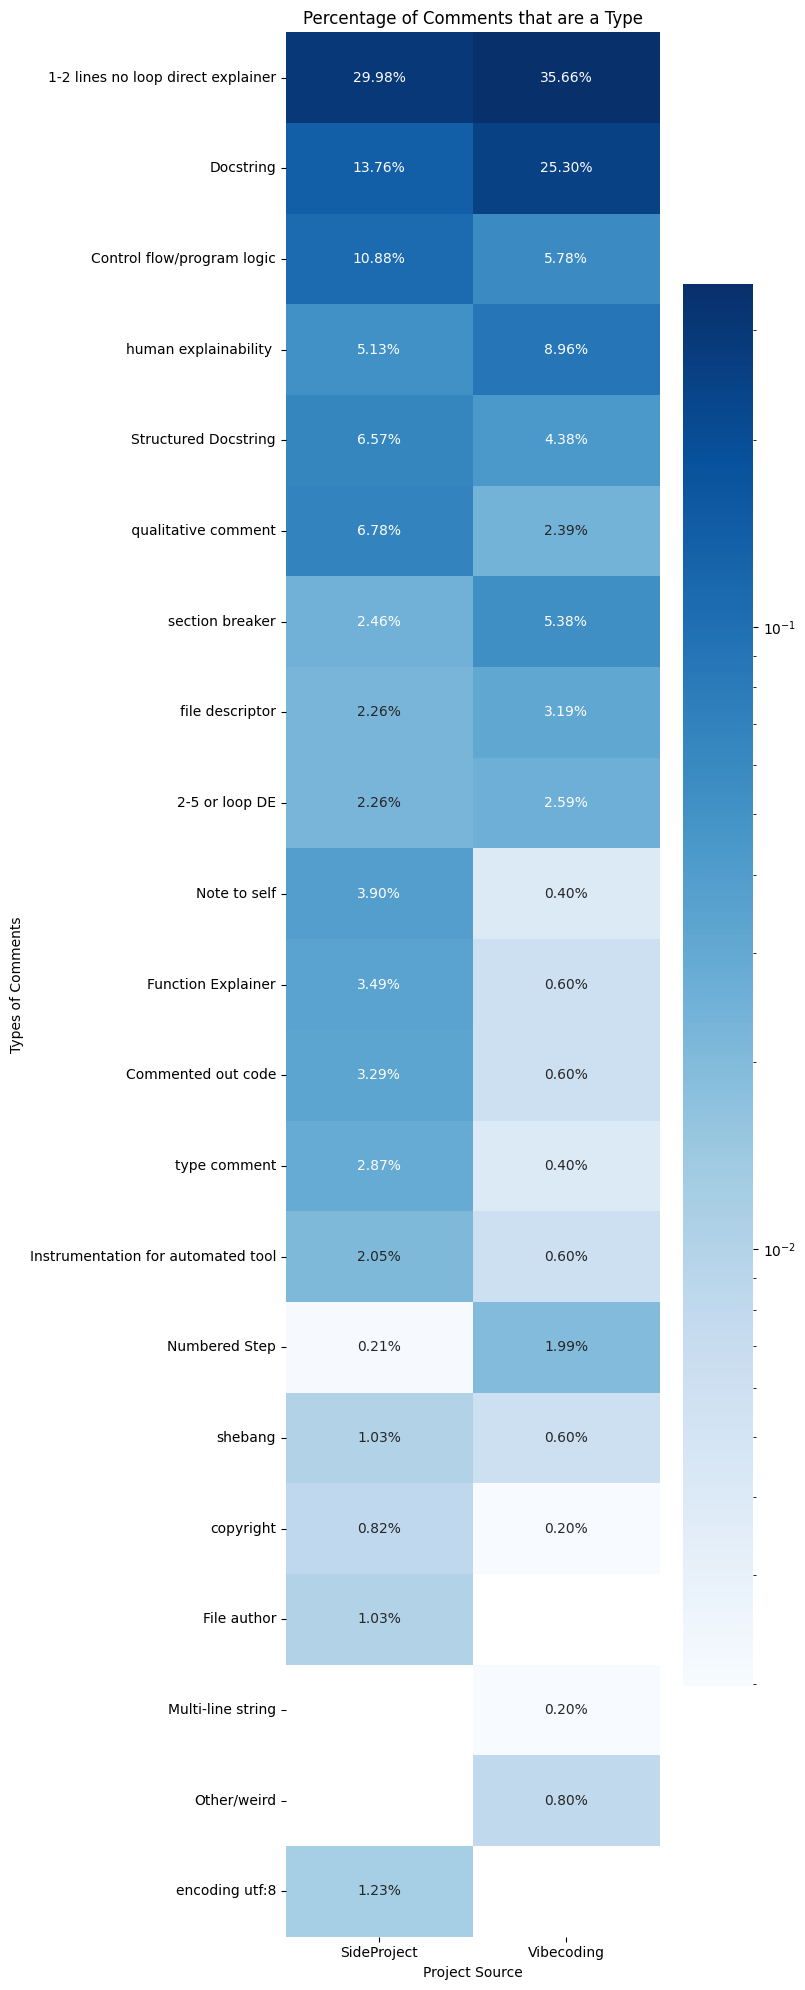

In [37]:
df = heatmap_df.drop('sum', axis=1)
plt.figure(figsize=(8, 20))
sns.heatmap(
df[:25],
annot=True,
fmt=".2%",
cmap="Blues",
norm=LogNorm(vmin=max(0, df[df > 0].min().min()),
                vmax=df.max().max())
)
plt.title("Percentage of Comments that are a Type")
plt.xlabel("Project Source")
plt.ylabel("Types of Comments")
plt.tight_layout()
plt.show()

In [38]:
type_augg = ffiles_df.groupby(["source", "aug code"]).size().reset_index(name="n_codes")

In [39]:
heatmap_augg = type_augg.pivot(index='aug code', columns='source', values='n_codes')
heatmap_augg.fillna(0, inplace=True)
heatmap_augg.head()

source,SideProject,Vibecoding
aug code,,
qualitative comment,33.0,12.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0
Direct Explainer,157.0,192.0
Docstring *,116.0,152.0


In [40]:
heatmap_augg["sum"] = heatmap_augg["SideProject"] + heatmap_augg["Vibecoding"]
heatmap_augg = heatmap_augg.sort_values(by = ["sum"], ascending = False) 
heatmap_augg["SideProject"] = heatmap_augg["SideProject"]/heatmap_augg["SideProject"].sum()
heatmap_augg["Vibecoding"] = heatmap_augg["Vibecoding"]/heatmap_augg["Vibecoding"].sum()

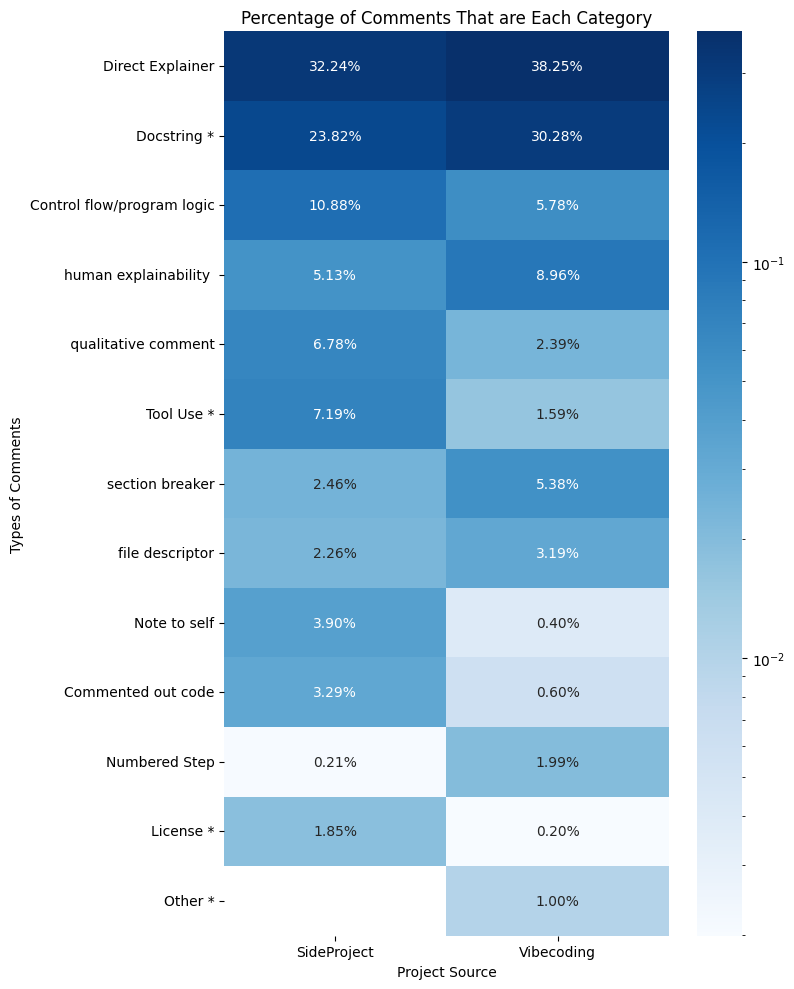

In [41]:
df = heatmap_augg.drop('sum', axis=1)
plt.figure(figsize=(8, 10))
sns.heatmap(
df[:25],
annot=True,
fmt=".2%",
cmap="Blues",
norm=LogNorm(vmin=max(0, df[df > 0].min().min()),
                vmax=df.max().max())
)
plt.title("Percentage of Comments That are Each Category")
plt.xlabel("Project Source")
plt.ylabel("Types of Comments")
plt.tight_layout()
plt.show()

## Total number of comments

In [42]:
colnames=["url","commit","proj_name","file_path","file_name","new_url","comments"]
comments = pd.read_csv("../dataset_features/comments.csv", names=colnames, header=None)
comments.drop_duplicates(inplace=True)

In [43]:
comments.head()

url  \
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis   

                                                                                                                  commit  \
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis/theia/autograde/autograde/exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis/theia/autograde/autograde/exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis/theia/autograde/autograde/exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis/theia/autograde/autograde/exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  Anubis/theia/autograde/autograde/exercise.py   

                                                                              proj_name  \
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  exercise.py   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  exercise.py   

                                                                                                                    file_path  \
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  https://github.com/GusSand/Anubis/blob/dced337...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  https://github.com/GusSand/Anubis/blob/dced337...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  https://github.com/GusSand/Anubis/blob/dced337...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  https://github.com/GusSand/Anubis/blob/dced337...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  https://github.com/GusSand/Anubis/blob/dced337...   

                                                                                                                    file_name  \
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  \ndef verify_required(exercise: Exercise, _: U...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  \ndef verify_command_regex(exercise: Exercise,...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  \ndef verify_output_regex(exercise: Exercise, ...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b          isdir = os.path.isdir(path)\n\n       ...   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b              raise RejectionException(f'File or...   

                                                                            new_url  \
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  comment   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  comment   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  comment   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  comment   
                                  dced3375debfbe06362d2da03f71ea80b29fb81b  comment   

                                                                                                        comments  
https://github.com/GusSand/Anubis dced3375debfbe06362d2da03f71ea80b29fb81b  # Veri

In [44]:
len(comments)

418802

In [45]:
source_df.head()

,url,commit,error,time_out,SideProject,Vibecoding
0,https://github.com/Skowt/Loadr,c2ead4af6a33aed6ed79684f2346de6a3f12fe5a,False,False,True,False
1,https://github.com/AI-Spawn/Save-The-Turtles,4747b9d40aeb6c1cbc73eb0802008c4afff686d9,False,False,True,False
2,https://github.com/YigitGunduc/cycle,26eb2a3b4b61505b7f21395e0165a1cee3973090,False,False,True,False
3,https://github.com/saurabh0719/jett,3f57c4a8a626678f27305c54d13237eb583c30b4,False,False,True,False
4,https://github.com/tn/climood,4dae3cae768245a169e8abeccb457558fac8c112,False,False,True,False


In [46]:
mask = (source_df["Vibecoding"])
name_df = source_df[mask]
url_set = set(name_df["url"])
mask = (comments["url"].isin(url_set))
name_comments = comments[mask]

In [47]:
len(name_comments)

0

In [48]:
mask = (source_df["SideProject"])
name_df = source_df[mask]
url_set = set(name_df["url"])
mask = (comments["url"].isin(url_set))
name_comments_sc = comments[mask]

In [49]:
len(name_comments_sc)

0

In [50]:
len(name_comments.url.unique())

0

In [51]:
len(name_comments.file_path.unique())

0

## Removing docstrings and computing stastical significance

In [52]:
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

In [53]:
ffiles_df.head()

,Unnamed: 0,url,commit,proj_name,file_path,file_name,new_url,comments,Notes,Code A,m,double check,Why,AI typesetting,syntax error,human-like,Fun Comment,source,aug code
0,213881.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/tests/integration/test_routin...,test_routing.py,https://github.com/Egham-7/adaptive/blob/03c44...,"""""""Test that alternatives has reasonab...",NaN,Control flow/program logic,Control flow/program logic,False,False,False,False,False,False,Vibecoding,Control flow/program logic
1,214192.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/src/nordlys/clustering/spectr...,spectral.py,https://github.com/Egham-7/adaptive/blob/03c44...,"\n def predict(self, embeddings: np.ndarray...",NaN,Structured Docstring,NaN,False,False,False,False,False,False,Vibecoding,Docstring *
2,178359.0,https://github.com/hh54188/ai-assistant-chrome...,99df8d7adc5d5d2925bfa3bcbca4e4afbdb1d88e,ai-assistant-chrome-extension,ai-assistant-chrome-extension/agents/adk-agent...,github_operations.py,https://github.com/hh54188/ai-assistant-chrome...,"repo = g.get_repo(""hh54188/horace-jeky...",NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding,Direct Explainer
3,324344.0,https://github.com/Ark0N/AI-Code-Executor,acdbbd5116a8aa932e71ac18aa90d66144d7123c,AI-Code-Executor,AI-Code-Executor/backend/main.py,main.py,https://github.com/Ark0N/AI-Code-Executor/blob...,"@app.get(""/api/models/lmstudio"")\nasync def ge...",NaN,Docstring,NaN,False,False,False,False,False,False,Vibecoding,Docstring *
4,332211.0,https://github.com/TaimoorKhan10/AI-Fairness-E...,74ad5f68c942943abfc85c714bb09c4245c583e4,AI-Fairness-Explainability-Toolkit,AI-Fairness-Explainability-Toolkit/afet/tests/...,test_model_comparison.py,https://github.com/TaimoorKhan10/AI-Fairness-E...,from sklearn.model_selection import train_test...,NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding,Direct Explainer


In [54]:
no_ds = ffiles_df[ffiles_df["aug code"] != "Docstring *"]

In [55]:
no_ds.head()

,Unnamed: 0,url,commit,proj_name,file_path,file_name,new_url,comments,Notes,Code A,m,double check,Why,AI typesetting,syntax error,human-like,Fun Comment,source,aug code
0,213881.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/tests/integration/test_routin...,test_routing.py,https://github.com/Egham-7/adaptive/blob/03c44...,"""""""Test that alternatives has reasonab...",NaN,Control flow/program logic,Control flow/program logic,False,False,False,False,False,False,Vibecoding,Control flow/program logic
2,178359.0,https://github.com/hh54188/ai-assistant-chrome...,99df8d7adc5d5d2925bfa3bcbca4e4afbdb1d88e,ai-assistant-chrome-extension,ai-assistant-chrome-extension/agents/adk-agent...,github_operations.py,https://github.com/hh54188/ai-assistant-chrome...,"repo = g.get_repo(""hh54188/horace-jeky...",NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding,Direct Explainer
4,332211.0,https://github.com/TaimoorKhan10/AI-Fairness-E...,74ad5f68c942943abfc85c714bb09c4245c583e4,AI-Fairness-Explainability-Toolkit,AI-Fairness-Explainability-Toolkit/afet/tests/...,test_model_comparison.py,https://github.com/TaimoorKhan10/AI-Fairness-E...,from sklearn.model_selection import train_test...,NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding,Direct Explainer
6,320787.0,https://github.com/summitsingh/ai-instagram-or...,3382a3985c4a814d9d00a5a59c7880928a8ee446,ai-instagram-organizer,ai-instagram-organizer/ai_instagram_organizer.py,ai_instagram_organizer.py,https://github.com/summitsingh/ai-instagram-or...,\n except requests.exceptio...,NaN,human explainability,NaN,False,False,False,False,False,False,Vibecoding,human explainability
8,325200.0,https://github.com/fabriziosalmi/aidlp,1967cd6eaad9ff489752f9734ce75aa301490a0a,aidlp,aidlp/verify_dlp.py,verify_dlp.py,https://github.com/fabriziosalmi/aidlp/blob/19...,sys.path.append(os.getcwd())\n\nfrom src.dlp_e...,NaN,Instrumentation for automated tool,NaN,False,False,False,False,False,False,Vibecoding,Tool Use *


In [56]:
type_df = no_ds.groupby(["source", "aug code"]).size().reset_index(name="n_codes")
heatmap_df = type_df.pivot(index='aug code', columns='source', values='n_codes')

In [57]:
heatmap_df.head()

source,SideProject,Vibecoding
aug code,,
qualitative comment,33.0,12.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0
Direct Explainer,157.0,192.0
License *,9.0,1.0


In [58]:


chi2, p, dof, expected = chi2_contingency(heatmap_df)

print("Global chi-squared p-value:", p)

results = []

for row in df.index:

    side_this = df.loc[row, "SideProject"]
    vibe_this = df.loc[row, "Vibecoding"]



Global chi-squared p-value: nan


In [59]:
counts = heatmap_df[["SideProject", "Vibecoding"]]

# Convert to numeric and replace blanks/NaNs with 0
counts_2 = counts.apply(pd.to_numeric, errors="coerce").fillna(0)

In [60]:
counts_2.head()

source,SideProject,Vibecoding
aug code,,
qualitative comment,33.0,12.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0
Direct Explainer,157.0,192.0
License *,9.0,1.0


In [61]:
counts_2.SideProject.sum()

np.float64(371.0)

In [62]:
counts.head()

source,SideProject,Vibecoding
aug code,,
qualitative comment,33.0,12.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0
Direct Explainer,157.0,192.0
License *,9.0,1.0


In [63]:
counts.Vibecoding.sum()

np.float64(350.0)

In [64]:
counts = counts[["SideProject", "Vibecoding"]].copy()

print("Any negative values?")
print((counts < 0).any())

print("\nRows with negative values:")
print(counts[(counts < 0).any(axis=1)])

print("\nMinimum values:")
print(counts.min())

Any negative values?
source
SideProject    False
Vibecoding     False
dtype: bool

Rows with negative values:
Empty DataFrame
Columns: [SideProject, Vibecoding]
Index: []

Minimum values:
source
SideProject    1.0
Vibecoding     1.0
dtype: float64


# Add a big chi squared test across all of them

In [65]:
counts.index

Index([' qualitative comment', 'Commented out code',
       'Control flow/program logic', 'Direct Explainer', 'License *',
       'Note to self', 'Numbered Step', 'Other *', 'Tool Use *',
       'file descriptor', 'human explainability ', 'section breaker'],
      dtype='str', name='aug code')

In [66]:
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

# Example dataframe structure:
#                          SideProject  Vibecoding
# qualitative comment              33           12
# Commented out code               16            3
# Control flow/program logic       53           29
# Direct Explainer                157          192
# Docstring *                     116          152N

# -----------------------------
# GLOBAL CHI-SQUARED TEST
# -----------------------------

chi2, p, dof, expected = chi2_contingency(counts_2)

print("Global chi-squared p-value:", p)

# -----------------------------
# PER-ROW SIGNIFICANCE TESTS
# -----------------------------
#
# For each row/category:
# compare:
#
# this category
# vs
# all other categories combined
#
# Then apply multiple comparison correction.

results = []

for row in counts_2.index:

    side_this = counts_2.loc[row, "SideProject"]
    vibe_this = counts_2.loc[row, "Vibecoding"]

    side_other = counts_2["SideProject"].sum() - side_this
    vibe_other = counts_2["Vibecoding"].sum() - vibe_this

    contingency = [
        [side_this, vibe_this],
        [side_other, vibe_other]
    ]

    chi2, p, dof, expected = chi2_contingency(contingency)
    # print(contingency)
    # assoc = association(np.asarray(contingency, dtype=int), method="cramer")
    p_sp = side_this / counts_2["SideProject"].sum()
    p_vb = vibe_this / counts_2["Vibecoding"].sum()

    h = (
        2 * np.arcsin(np.sqrt(p_vb))
        - 2 * np.arcsin(np.sqrt(p_sp))
    )

    # proportions
    side_rate = side_this / counts_2["SideProject"].sum()
    vibe_rate = vibe_this / counts_2["Vibecoding"].sum()
    print(counts_2["SideProject"].sum())

    results.append({
        "category": row,
        "side_count": side_this,
        "vibe_count": vibe_this,
        "side_rate": side_rate,
        "vibe_rate": vibe_rate,
        "difference": vibe_rate - side_rate,
        "association": h,
        "p_raw": p
    })

results_df = pd.DataFrame(results)

# -----------------------------
# MULTIPLE COMPARISON CORRECTION
# -----------------------------

reject, p_corr, _, _ = multipletests(
    results_df["p_raw"],
    method="fdr_bh"
)

results_df["p_corrected"] = p_corr
results_df["significant"] = reject

# sort by significance
results_df = results_df.sort_values("p_corrected")

print(results_df)

Global chi-squared p-value: 1.2815563461455429e-14
371.0
371.0
371.0
371.0
371.0
371.0
371.0
371.0
371.0
371.0
371.0
371.0
                      category  side_count  vibe_count  side_rate  vibe_rate  \
8                   Tool Use *        35.0         8.0   0.094340   0.022857   
5                 Note to self        19.0         2.0   0.051213   0.005714   
3             Direct Explainer       157.0       192.0   0.423181   0.548571   
0          qualitative comment        33.0        12.0   0.088949   0.034286   
1           Commented out code        16.0         3.0   0.043127   0.008571   
10       human explainability         25.0        45.0   0.067385   0.128571   
6                Numbered Step         1.0        10.0   0.002695   0.028571   
11             section breaker        12.0        27.0   0.032345   0.077143   
2   Control flow/program logic        53.0        29.0   0.142857   0.082857   
4                    License *         9.0         1.0   0.024259   0.002857 

In [67]:
results_df.to_csv("all_comments_results.csv")

## find number of projects that have python comments

In [50]:
mask = (source_df["Vibecoding"])
name_df = source_df[mask]
url_set = set(name_df["url"])
mask = (comments["url"].isin(url_set))
name_comments = comments[mask]
comments ["source"] =  ["Vibecoding" if x in url_set else "SideProject" for x in comments['url']]

In [51]:
print(comments["source"][int(comments.index[comments.proj_name == "Anubis"].max())])
print(comments["source"][int(comments.index[comments.proj_name == "Ben-s-Software-"].max())])

ValueError: cannot convert float NaN to integer

In [ ]:
comments.source.value_counts()

source
Vibecoding     351988
SideProject     56345
Name: count, dtype: int64

In [ ]:
comments.head()

,url,commit,proj_name,file_path,file_name,new_url,comments,source
0,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/manage.py,manage.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,"#!/usr/bin/env python\n""""""Django's command-lin...",SideProject
1,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/manage.py,manage.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,"#!/usr/bin/env python\n""""""Django's command-lin...",SideProject
2,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/manage.py,manage.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,"\ndef main():\n """"""Run administrative tasks...",SideProject
3,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/organizations/tests.py,tests.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,from django.test import TestCase\n\n# Create y...,SideProject
4,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/organizations/views.py,views.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,from django.shortcuts import render\n\n# Creat...,SideProject


In [ ]:
new_comments = comments.groupby(["file_path", "source"]).size().reset_index(name="n_files")
new_comments.head()

,file_path,source,n_files
0,AI-Code-Executor/backend/__init__.py,Vibecoding,1
1,AI-Code-Executor/backend/anthropic_client.py,Vibecoding,10
2,AI-Code-Executor/backend/code_executor.py,Vibecoding,49
3,AI-Code-Executor/backend/database.py,Vibecoding,8
4,AI-Code-Executor/backend/gemini_client.py,Vibecoding,10


Text(0, 0.5, 'Number of Comments per File')

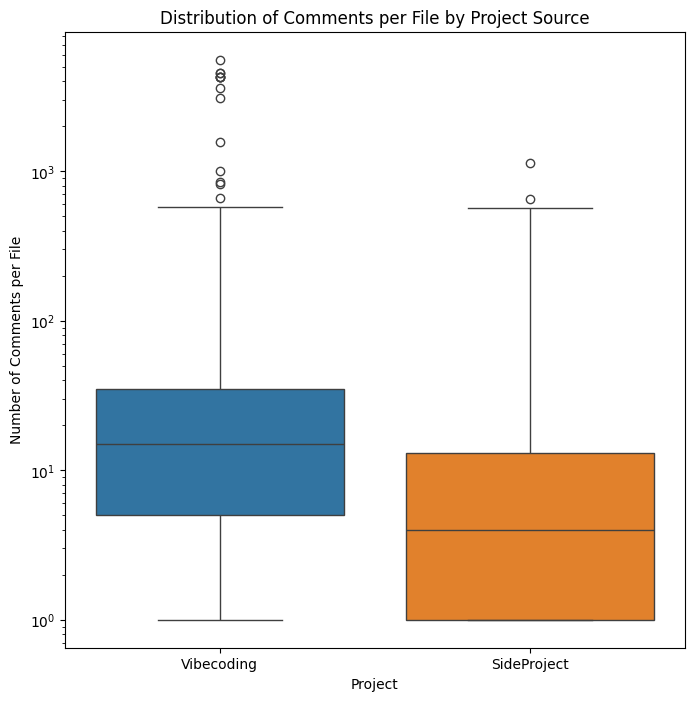

In [ ]:
plt.figure(figsize=(8, 8))
sns.boxplot(
    data=new_comments,
    x="source",
    y="n_files",
    log_scale=True,
    hue="source",
    hue_order=[ "Vibecoding", "SideProject"],
    order=["Vibecoding", "SideProject"],
    )
plt.title("Distribution of Comments per File by Project Source")
plt.xlabel("Project")
plt.ylabel("Number of Comments per File")

In [ ]:
comm_vc = new_comments[new_comments["source"] == "Vibecoding"]
comm_sp = new_comments[new_comments["source"] == "SideProject"]

In [ ]:
stat, p = mannwhitneyu(comm_vc["n_files"], comm_sp["n_files"], alternative="two-sided")

print(p)
print(stat)

8.604848082301425e-272
30203976.0


### Normalize by file length

In [ ]:
comments.head()

,url,commit,proj_name,file_path,file_name,new_url,comments,source
0,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/manage.py,manage.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,"#!/usr/bin/env python\n""""""Django's command-lin...",SideProject
1,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/manage.py,manage.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,"#!/usr/bin/env python\n""""""Django's command-lin...",SideProject
2,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/manage.py,manage.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,"\ndef main():\n """"""Run administrative tasks...",SideProject
3,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/organizations/tests.py,tests.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,from django.test import TestCase\n\n# Create y...,SideProject
4,https://github.com/ctk-hq/ctk,a0390526216e3fc46bb82180d87998d3a62635f9,ctk,ctk/services/backend/src/organizations/views.py,views.py,https://github.com/ctk-hq/ctk/blob/a0390526216...,from django.shortcuts import render\n\n# Creat...,SideProject


In [ ]:
all_files="../dataset_features/files_raw.csv"
all_files_df = pd.read_csv(all_files, names=["url", "proj", "file_path", "file_name", "extn", "n_lines", "n_blank", "n_char"])
all_files_py = all_files_df[all_files_df["extn"] == "py"]

In [ ]:
all_files_py.head()

,url,proj,file_path,file_name,extn,n_lines,n_blank,n_char
7835,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/__init__.py,__init__.py,py,0,0,0
7840,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,py,0,0,0
7842,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,py,36,8,626
7843,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,py,1,0,26
7844,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,py,137,28,3827


In [ ]:
new_comments = comments.groupby(["file_path", "source"]).size().reset_index(name="n_comm")
#new_comments.head()
new_all = all_files_py.merge(new_comments, on="file_path") #fuck not like this

In [ ]:
new_all

,url,proj,file_path,file_name,extn,n_lines,n_blank,n_char,source,n_comm,norm
0,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,py,137,28,3827,SideProject,7,0.051095
1,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/app.py,app.py,py,110,14,2384,SideProject,3,0.027273
2,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autosave/app.py,app.py,py,153,29,3777,SideProject,9,0.058824
3,https://github.com/GusSand/Anubis,Anubis,Anubis/api/migrations/env.py,env.py,py,113,27,2691,SideProject,7,0.061947
4,https://github.com/GusSand/Anubis,Anubis,Anubis/api/migrations/versions/b17b8f54b3af_rm...,b17b8f54b3af_rm_theia_persistent_column_from_.py,py,36,7,682,SideProject,6,0.166667
...,...,...,...,...,...,...,...,...,...,...,...
15305,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/__i...,__init__.py,py,48,8,1494,Vibecoding,10,0.208333
15306,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sys...,system_management_service.py,py,423,80,11348,Vibecoding,49,0.115839
15307,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/bas...,base_service.py,py,140,31,2629,Vibecoding,12,0.085714
15308,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/cod...,code_intelligence_service.py,py,245,43,5991,Vibecoding,24,0.097959


In [ ]:
new_all["norm"] = new_all["n_comm"]/new_all["n_lines"]

Text(0, 0.5, 'Number of Comments per File (normalized by file length)')

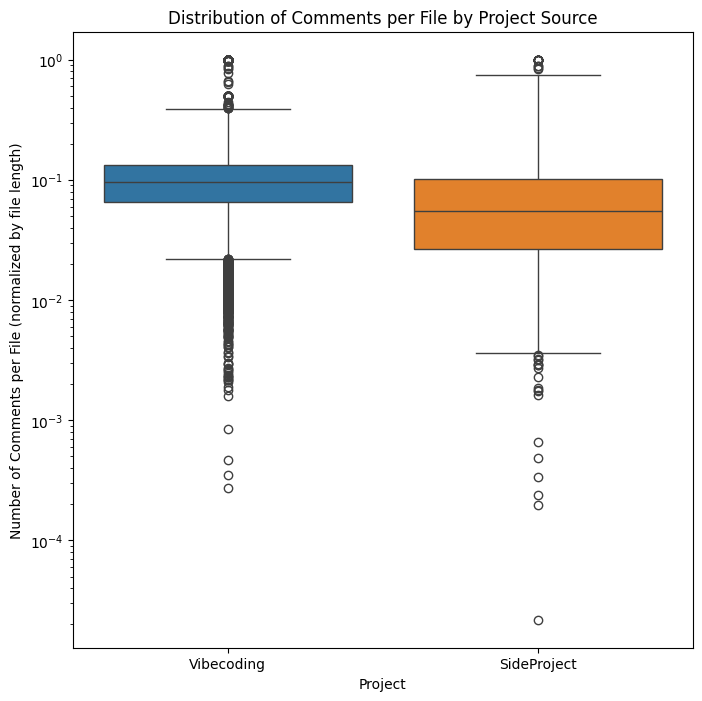

In [ ]:
plt.figure(figsize=(8, 8))
sns.boxplot(
    data=new_all,
    x="source",
    y="norm",
    log_scale=True,
    hue="source",
    hue_order=[ "Vibecoding", "SideProject"],
    order=["Vibecoding", "SideProject"],
    )
plt.title("Distribution of Comments per File by Project Source")
plt.xlabel("Project")
plt.ylabel("Number of Comments per File (normalized by file length)")

In [ ]:
comm_vc = new_all[new_all["source"] == "Vibecoding"]
comm_sp = new_all[new_all["source"] == "SideProject"]

In [ ]:
stat, p = mannwhitneyu(comm_vc["norm"], comm_sp["norm"], alternative="two-sided") #do I need this?

print(p)
print(stat)

3.583414658388786e-263
29894972.0


## Why

In [62]:
ffiles_df

,Unnamed: 0,url,commit,proj_name,file_path,file_name,new_url,comments,Notes,Code A,m,double check,Why,AI typesetting,syntax error,human-like,Fun Comment,source,aug code
0,213881.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/tests/integration/test_routin...,test_routing.py,https://github.com/Egham-7/adaptive/blob/03c44...,"""""""Test that alternatives has reasonab...",NaN,Control flow/program logic,Control flow/program logic,False,False,False,False,False,False,Vibecoding,Control flow/program logic
1,214192.0,https://github.com/Egham-7/adaptive,03c4439b2429ffe4ebc91812475851091d1c65e3,adaptive,adaptive/nordlys/src/nordlys/clustering/spectr...,spectral.py,https://github.com/Egham-7/adaptive/blob/03c44...,"\n def predict(self, embeddings: np.ndarray...",NaN,Structured Docstring,NaN,False,False,False,False,False,False,Vibecoding,Docstring *
2,178359.0,https://github.com/hh54188/ai-assistant-chrome...,99df8d7adc5d5d2925bfa3bcbca4e4afbdb1d88e,ai-assistant-chrome-extension,ai-assistant-chrome-extension/agents/adk-agent...,github_operations.py,https://github.com/hh54188/ai-assistant-chrome...,"repo = g.get_repo(""hh54188/horace-jeky...",NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding,Direct Explainer
3,324344.0,https://github.com/Ark0N/AI-Code-Executor,acdbbd5116a8aa932e71ac18aa90d66144d7123c,AI-Code-Executor,AI-Code-Executor/backend/main.py,main.py,https://github.com/Ark0N/AI-Code-Executor/blob...,"@app.get(""/api/models/lmstudio"")\nasync def ge...",NaN,Docstring,NaN,False,False,False,False,False,False,Vibecoding,Docstring *
4,332211.0,https://github.com/TaimoorKhan10/AI-Fairness-E...,74ad5f68c942943abfc85c714bb09c4245c583e4,AI-Fairness-Explainability-Toolkit,AI-Fairness-Explainability-Toolkit/afet/tests/...,test_model_comparison.py,https://github.com/TaimoorKhan10/AI-Fairness-E...,from sklearn.model_selection import train_test...,NaN,1-2 lines no loop direct explainer,NaN,False,False,False,False,False,False,Vibecoding,Direct Explainer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,51554.0,https://github.com/moon004/YouDeez,70a72f52064615d2d4aa51e37376f3d4ff47b718,YouDeez,YouDeez/vendor/youtube-dl-getsize/youtube_dl/_...,__init__.py,https://github.com/moon004/YouDeez/blob/70a72f...,download_archive_fn = expand_path(opts.dow...,NaN,section breaker,NaN,False,False,False,False,False,False,SideProject,section breaker
986,51905.0,https://github.com/moon004/YouDeez,70a72f52064615d2d4aa51e37376f3d4ff47b718,YouDeez,YouDeez/vendor/youtube-dl-getsize/youtube_dl/Y...,YoutubeDL.py,https://github.com/moon004/YouDeez/blob/70a72f...,"\nclass YoutubeDL(object):\n """"""YoutubeDL c...",Longest one,Structured Docstring,NaN,False,False,False,False,False,False,SideProject,Docstring *
987,30367.0,https://github.com/uree/youtube-sampler,6c5001b12a06dea2b87f06aff86b2d5678c1b411,youtube-sampler,youtube-sampler/api/app/app.py,app.py,https://github.com/uree/youtube-sampler/blob/6...,print(segment_len)\n\n # audio = ytsamp...,NaN,Commented out code,NaN,False,False,False,False,False,False,SideProject,Commented out code
988,3682.0,https://github.com/prabhatsharma/zinc,d66702daf6cfef09ad08964f538a5fe309a2e230,zinc,zinc/examples/search.py,search.py,https://github.com/prabhatsharma/zinc/blob/d66...,"}\n\n# params = {\n# ""search_type"": ""query...",NaN,Commented out code,NaN,False,False,False,False,False,False,SideProject,Commented out code


In [63]:
why_df = ffiles_df.groupby(["source", "aug code", "Why"]).size().reset_index(name="n_codes")

In [64]:
sp = why_df[why_df["source"] == "SideProject"]
vc = why_df[why_df["source"] == "Vibecoding"]

In [65]:
vc

,source,aug code,Why,n_codes
18,Vibecoding,qualitative comment,False,8
19,Vibecoding,qualitative comment,True,4
20,Vibecoding,Commented out code,False,3
21,Vibecoding,Control flow/program logic,False,19
22,Vibecoding,Control flow/program logic,True,10
23,Vibecoding,Direct Explainer,False,172
24,Vibecoding,Direct Explainer,True,20
25,Vibecoding,Docstring *,False,152
26,Vibecoding,License *,False,1
27,Vibecoding,Note to self,False,1


In [66]:
sp

,source,aug code,Why,n_codes
0,SideProject,qualitative comment,False,25
1,SideProject,qualitative comment,True,8
2,SideProject,Commented out code,False,16
3,SideProject,Control flow/program logic,False,23
4,SideProject,Control flow/program logic,True,30
5,SideProject,Direct Explainer,False,134
6,SideProject,Direct Explainer,True,23
7,SideProject,Docstring *,False,115
8,SideProject,Docstring *,True,1
9,SideProject,License *,False,9


In [67]:
type_augg

,source,aug code,n_codes
0,SideProject,qualitative comment,33
1,SideProject,Commented out code,16
2,SideProject,Control flow/program logic,53
3,SideProject,Direct Explainer,157
4,SideProject,Docstring *,116
5,SideProject,License *,9
6,SideProject,Note to self,19
7,SideProject,Numbered Step,1
8,SideProject,Tool Use *,35
9,SideProject,file descriptor,11


In [68]:
sp_true = sp[sp["Why"] == True]
vc_true = vc[vc["Why"] == True]

In [69]:
sp_true

,source,aug code,Why,n_codes
1,SideProject,qualitative comment,True,8
4,SideProject,Control flow/program logic,True,30
6,SideProject,Direct Explainer,True,23
8,SideProject,Docstring *,True,1
11,SideProject,Note to self,True,5
16,SideProject,human explainability,True,1


In [70]:
vc_true

,source,aug code,Why,n_codes
19,Vibecoding,qualitative comment,True,4
22,Vibecoding,Control flow/program logic,True,10
24,Vibecoding,Direct Explainer,True,20
28,Vibecoding,Note to self,True,1
30,Vibecoding,Numbered Step,True,1
32,Vibecoding,Other *,True,1
36,Vibecoding,human explainability,True,1


In [71]:
sp_true["total"] = [33, 53, 157, 116, 19, 25]
vc_true["total"] = [12, 29, 192, 2, 10, 5, 45]

In [72]:
sp_true["percent"] = sp_true["n_codes"]/sp_true["total"]
vc_true["percent"] = vc_true["n_codes"]/vc_true["total"]

In [73]:
vc_true

,source,aug code,Why,n_codes,total,percent
19,Vibecoding,qualitative comment,True,4,12,0.333333
22,Vibecoding,Control flow/program logic,True,10,29,0.344828
24,Vibecoding,Direct Explainer,True,20,192,0.104167
28,Vibecoding,Note to self,True,1,2,0.500000
30,Vibecoding,Numbered Step,True,1,10,0.100000
32,Vibecoding,Other *,True,1,5,0.200000
36,Vibecoding,human explainability,True,1,45,0.022222


In [74]:
counts_all = pd.concat([sp_true, vc_true], axis=0).fillna(0)

In [75]:
counts_all

,source,aug code,Why,n_codes,total,percent
1,SideProject,qualitative comment,True,8,33,0.242424
4,SideProject,Control flow/program logic,True,30,53,0.566038
6,SideProject,Direct Explainer,True,23,157,0.146497
8,SideProject,Docstring *,True,1,116,0.008621
11,SideProject,Note to self,True,5,19,0.263158
16,SideProject,human explainability,True,1,25,0.040000
19,Vibecoding,qualitative comment,True,4,12,0.333333
22,Vibecoding,Control flow/program logic,True,10,29,0.344828
24,Vibecoding,Direct Explainer,True,20,192,0.104167
28,Vibecoding,Note to self,True,1,2,0.500000


In [ ]:
heatmap_df = counts_all.pivot(index='aug code', columns='source', values='percent')
heatmap_df.fillna(0,inplace=True)
heatmap_df

source,SideProject,Vibecoding
aug code,,
qualitative comment,0.242424,0.333333
Control flow/program logic,0.566038,0.344828
Direct Explainer,0.146497,0.104167
Docstring *,0.008621,0.000000
Note to self,0.263158,0.500000
Numbered Step,0.000000,0.100000
Other *,0.000000,0.200000
human explainability,0.040000,0.022222


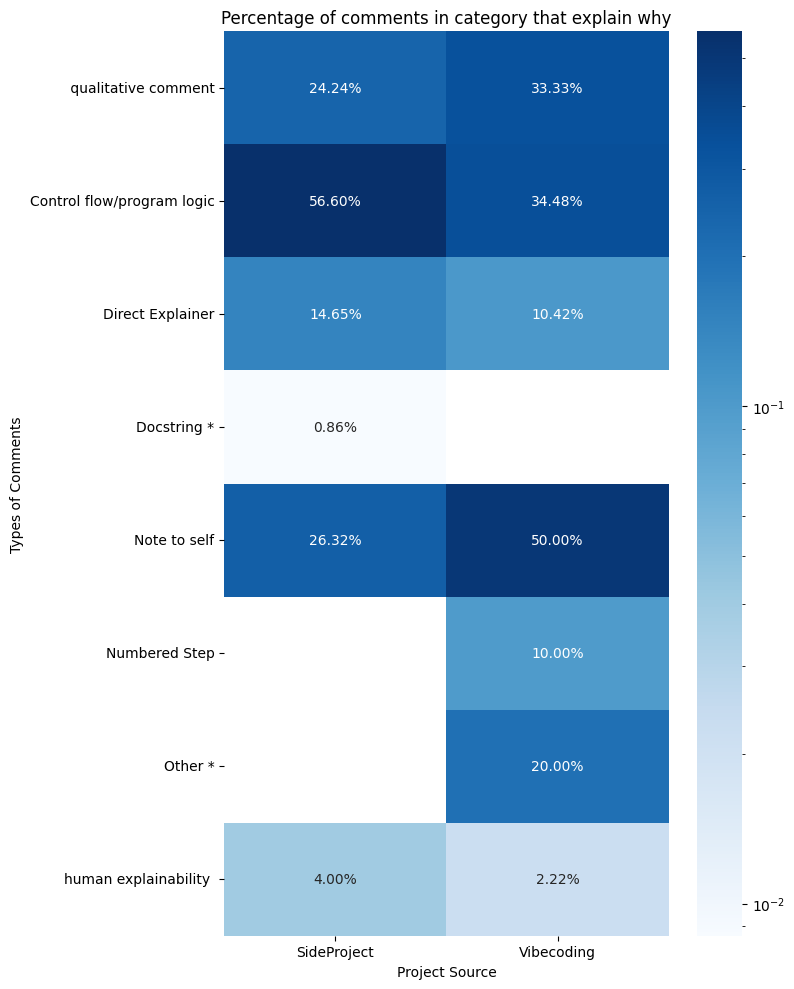

In [ ]:
df = heatmap_df
plt.figure(figsize=(8, 10))
sns.heatmap(
df,
annot=True,
fmt=".2%",
cmap="Blues",
norm=LogNorm(vmin=max(0, df[df > 0].min().min()),
                vmax=df.max().max())
)
plt.title("Percentage of comments in category that explain why")
plt.xlabel("Project Source")
plt.ylabel("Types of Comments")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

df = counts_all.copy()
print(df["aug code"].unique())

results = []

for why in df["aug code"].unique():
    # print(why)
    subset = df[df["aug code"] == why]

    if len(subset) != 2:
        print(why)
        continue

    side = subset[subset["source"] == "SideProject"].iloc[0]
    vibe = subset[subset["source"] == "Vibecoding"].iloc[0]

    count = [side["n_codes"], vibe["n_codes"]]
    nobs = [side["total"], vibe["total"]]

    p1 = side["percent"]
    p2 = vibe["percent"]

    # Cohen's h
    cohens_h = 2 * (
        np.arcsin(np.sqrt(p1)) -
        np.arcsin(np.sqrt(p2))
    )

    failures = [nobs[0] - count[0], nobs[1] - count[1]]
    # print(failures)

    if min(count + failures) < 5:
        table = [
            [count[0], failures[0]],
            [count[1], failures[1]]
        ]
        _, p = fisher_exact(table)
        test = "Fisher"
    else:
        _, p = proportions_ztest(count, nobs)
        test = "Two-proportion z"

    results.append({
        "Why": why,
        "SideProject %": p1,
        "Vibecoding %": p2,
        "Difference": p2 - p1,
        "Test": test,
        "p_value": p,
        "Cohens_h": cohens_h,
        "Abs_h": abs(cohens_h),
    })

results = pd.DataFrame(results)
print(results)

# Multiple-comparison correction
results["p_adj"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

results["Significant"] = results["p_adj"] < 0.05

# Magnitude of Cohen's h
results["Effect"] = pd.cut(
    results["Abs_h"],
    bins=[0, 0.2, 0.5, 0.8, np.inf],
    labels=["Negligible", "Small", "Medium", "Large"],
    include_lowest=True
)

results = results.sort_values("p_adj")

print(results)

<StringArray>
[      ' qualitative comment', 'Control flow/program logic',
           'Direct Explainer',                'Docstring *',
               'Note to self',      'human explainability ',
              'Numbered Step',                    'Other *']
Length: 8, dtype: str
Docstring *
Numbered Step
Other *
                          Why  SideProject %  Vibecoding %  Difference  \
0         qualitative comment       0.242424      0.333333    0.090909   
1  Control flow/program logic       0.566038      0.344828   -0.221210   
2            Direct Explainer       0.146497      0.104167   -0.042330   
3                Note to self       0.263158      0.500000    0.236842   
4       human explainability        0.040000      0.022222   -0.017778   

               Test   p_value  Cohens_h     Abs_h  
0            Fisher  0.704981 -0.201348  0.201348  
1  Two-proportion z  0.055366  0.448018  0.448018  
2  Two-proportion z  0.231335  0.128276  0.128276  
3            Fisher  0.500000 -0.

In [ ]:
results.to_csv("why_results.csv")

In [76]:
counts_all

,source,aug code,Why,n_codes,total,percent
1,SideProject,qualitative comment,True,8,33,0.242424
4,SideProject,Control flow/program logic,True,30,53,0.566038
6,SideProject,Direct Explainer,True,23,157,0.146497
8,SideProject,Docstring *,True,1,116,0.008621
11,SideProject,Note to self,True,5,19,0.263158
16,SideProject,human explainability,True,1,25,0.040000
19,Vibecoding,qualitative comment,True,4,12,0.333333
22,Vibecoding,Control flow/program logic,True,10,29,0.344828
24,Vibecoding,Direct Explainer,True,20,192,0.104167
28,Vibecoding,Note to self,True,1,2,0.500000


In [77]:
type_df.groupby("source").n_codes.sum()

source
SideProject    371
Vibecoding     350
Name: n_codes, dtype: int64

In [85]:
df_counts = counts_all.groupby(["source"]).agg({"n_codes": ["sum"]})#.reset_index(name="n_why")

In [91]:
df_counts

,n_codes,total
,sum,
source,,
SideProject,68,350
Vibecoding,38,371


In [87]:
df_counts["total"] = [350, 371]

In [83]:
from statsmodels.stats.proportion import proportions_ztest

In [103]:
count = [68,38]
nobs = [350,371]
_, p = proportions_ztest(count, nobs)

In [104]:
p

np.float64(0.0004992499968078398)

In [100]:

p1 = 68/350
p2 = 38/371
cohens_h = 2 * (
    np.arcsin(np.sqrt(p1)) -
    np.arcsin(np.sqrt(p2))
)
cohens_h

np.float64(0.26138732377376694)

In [ ]:
for item in sp_true["aug code"].unique():
    print(index_sp.iloc[0])
    print(item)

source     SideProject
Why               True
n_codes              8
total             None
percent           None
Name:  qualitative comment, dtype: object
 qualitative comment
source     SideProject
Why               True
n_codes              8
total             None
percent           None
Name:  qualitative comment, dtype: object
Control flow/program logic
source     SideProject
Why               True
n_codes              8
total             None
percent           None
Name:  qualitative comment, dtype: object
Direct Explainer
source     SideProject
Why               True
n_codes              8
total             None
percent           None
Name:  qualitative comment, dtype: object
Docstring *
source     SideProject
Why               True
n_codes              8
total             None
percent           None
Name:  qualitative comment, dtype: object
Note to self
source     SideProject
Why               True
n_codes              8
total             None
percent           None
Name:  qua

In [ ]:
counts

source,SideProject,Vibecoding
aug code,,
qualitative comment,33.0,12.0
Commented out code,16.0,3.0
Control flow/program logic,53.0,29.0
Direct Explainer,157.0,192.0
License *,9.0,1.0
Note to self,19.0,2.0
Numbered Step,1.0,10.0
Other *,NaN,5.0
Tool Use *,35.0,8.0


In [ ]:
type_augg

,source,aug code,n_codes
0,SideProject,qualitative comment,33
1,SideProject,Commented out code,16
2,SideProject,Control flow/program logic,53
3,SideProject,Direct Explainer,157
4,SideProject,Docstring *,116
5,SideProject,License *,9
6,SideProject,Note to self,19
7,SideProject,Numbered Step,1
8,SideProject,Tool Use *,35
9,SideProject,file descriptor,11


In [ ]:
type_augg.groupby("source").sum()

,aug code,n_codes
source,,
SideProject,qualitative commentCommented out codeControl ...,487
Vibecoding,qualitative commentCommented out codeControl ...,502


In [ ]:
counts_all.groupby("source").sum()

,aug code,Why,n_codes,total,percent
source,,,,,
SideProject,qualitative commentControl flow/program logic...,6,68,403,1.266737
Vibecoding,qualitative commentControl flow/program logic...,7,38,295,1.604550
